# Imports

In [ ]:
%pip install tqdm ipywidgets

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: tqdm in c:\users\obedg\appdata\local\packages\pythonsoftwarefoundation.python.3.11_qbz5n2kfra8p0\localcache\local-packages\python311\site-packages (4.67.3)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\obedg\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.Collecting seaborn
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\obedg\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [18]:
import os
import random
import copy
from tqdm.notebook import tqdm
import time
import torch
import pandas as pd
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader, Subset, random_split, Dataset
from torchvision import datasets, transforms
from torchvision import models
from sklearn.metrics import confusion_matrix

# Pre Data Augmentation

[cats] cat.3892.jpg - Raw Size: (500, 374)
[cats] cat.9388.jpg - Raw Size: (499, 375)
[cats] cat.1529.jpg - Raw Size: (300, 224)
[cats] cat.8531.jpg - Raw Size: (499, 301)
[dogs] dog.1391.jpg - Raw Size: (334, 291)
[dogs] dog.7022.jpg - Raw Size: (499, 477)
[dogs] dog.5995.jpg - Raw Size: (431, 325)
[dogs] dog.5617.jpg - Raw Size: (375, 272)


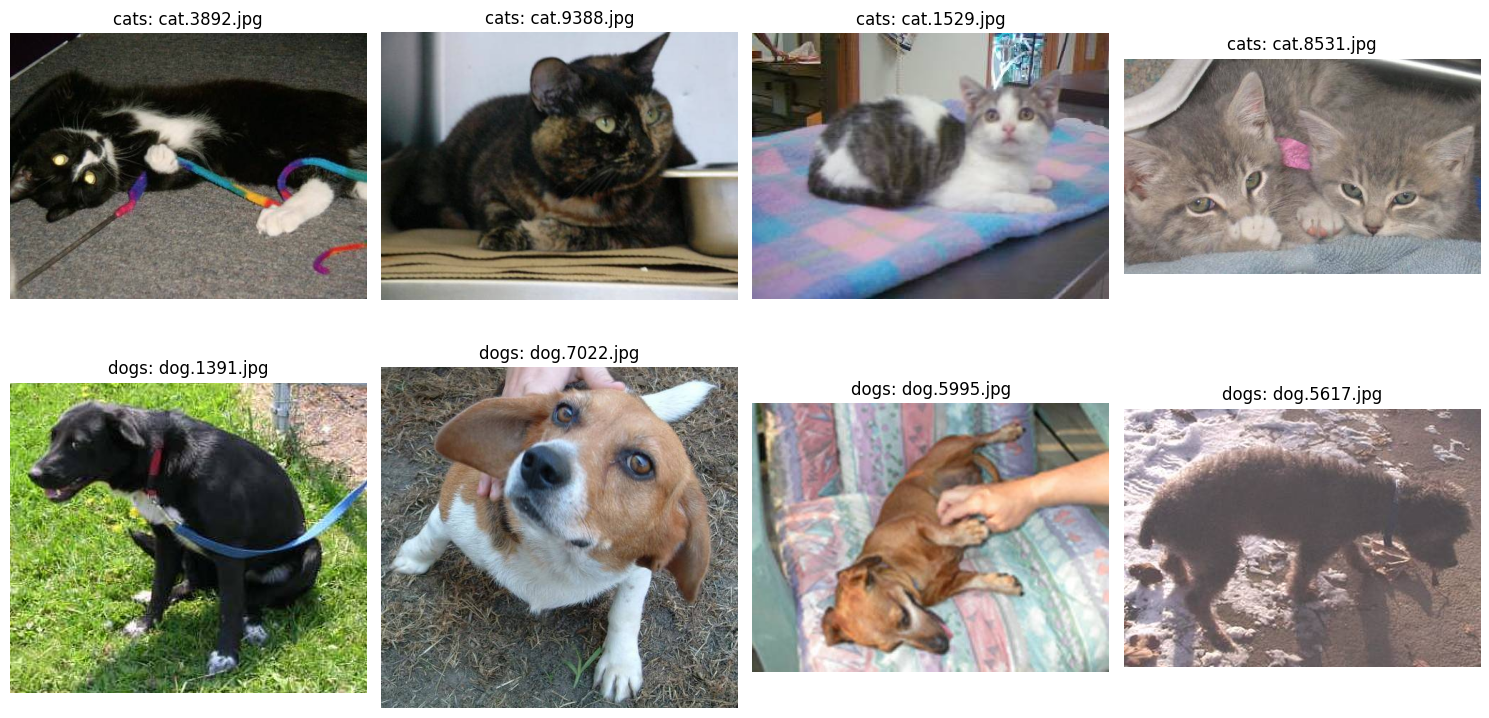

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data_path = 'ecse-415-winter-2026-dog-vs-cat-classification/train/train'

def show_random_samples(data_dir, num_samples=4):
    classes = ['cats', 'dogs']
    
    plt.figure(figsize=(15, 8))
    for i, clas in enumerate(classes):
        cls_dir = os.path.join(data_dir, clas)

        # file names
        images = [f for f in os.listdir(cls_dir) if f.endswith('.jpg')]
        
        # get a random sample
        samples = random.sample(images, num_samples)
        
        for j, img_name in enumerate(samples):
            img_path = os.path.join(cls_dir, img_name)
            img = Image.open(img_path)
            
            # 1, 2, 3, 4 for cats; 5, 6, 7, 8 for dogs
            plt.subplot(2, num_samples, i * num_samples + j + 1)
            plt.imshow(img)
            plt.title(f"{clas}: {img_name}")
            plt.axis('off')

            print(f"[{clas}] {img_name} - Raw Size: {img.size}")
            
    plt.tight_layout()
    plt.show()

show_random_samples(data_path)

In [20]:
cat_count = len(os.listdir(os.path.join(data_path, 'cats')))
dog_count = len(os.listdir(os.path.join(data_path, 'dogs')))

print(f"Cats: {cat_count}")
print(f"Dogs: {dog_count}")
print(f"Total: {cat_count + dog_count}")


Cats: 10021
Dogs: 9979
Total: 20000


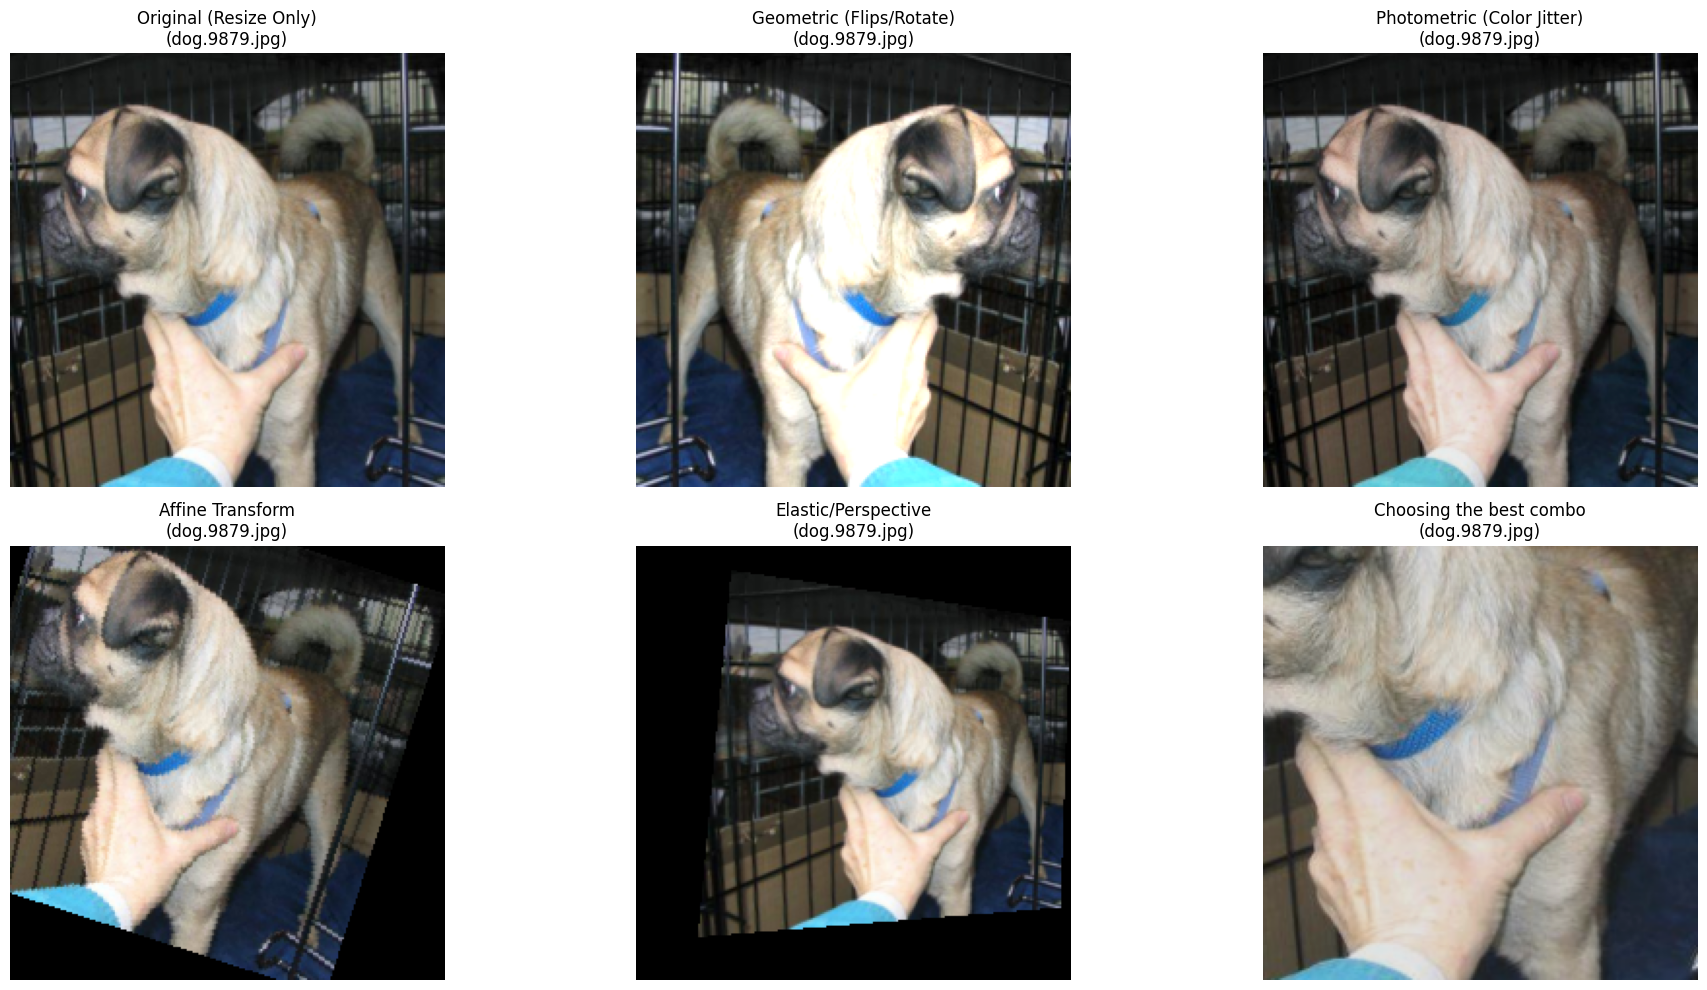

In [21]:
def get_random_img_pth(dir_path):
    cls = random.choice(['cats', 'dogs'])
    cls_dir = os.path.join(dir_path, cls)
    img_name = random.choice(os.listdir(cls_dir))
    return os.path.join(cls_dir, img_name)

# try different data augmentations
augmentations = {
    "Original (Resize Only)": transforms.Compose([
        transforms.Resize((224, 224))
    ]),
    
    "Geometric (Flips/Rotate)": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0), # Forced on for visualization
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2)
    ]),
    
    "Photometric (Color Jitter)": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
    ]),
    
    "Affine Transform": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomAffine(degrees=30, translate=(0.1, 0.1), scale=(0.8, 1.2))
    ]),
    
    "Elastic/Perspective": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomPerspective(distortion_scale=0.5, p=1.0)
    ]),
    
    "Choosing the best combo": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2, 0.2, 0.2)
    ])
}

#data_dir = 'ecse-415-winter-2026-dog-vs-cat-classification/train/train'
img_path = get_random_img_pth(data_path)
img = Image.open(img_path).convert('RGB')

plt.figure(figsize=(20, 10))

for i, (name, policy) in enumerate(augmentations.items()):
    augmented_img = policy(img)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_img)
    plt.title(f"{name}\n({img_path.split(os.sep)[-1]})", fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [22]:
# 1. Define the actual policies
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet normalization
])

# val_transform = transforms.Compose([
#     transforms.Resize((256, 256)), # Resize a bit larger
#     transforms.CenterCrop(224),    # Crop the exact center
#     transforms.ToTensor(),
#     transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
# ])

# split 80/20
#data_dir = 'ecse-415-winter-2026-dog-vs-cat-classification/train/train'
full_dataset = datasets.ImageFolder(data_path, transform=train_transform)

# train_size = int(0.8 * len(full_dataset))
# val_size = len(full_dataset) - train_size
# seed = torch.Generator().manual_seed(42)
# train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=seed)

# # CRITICAL FIX: Override the transform for the validation split so it doesn't use random crops
# val_dataset.dataset = copy.copy(full_dataset)
# val_dataset.dataset.transform = val_transform

# 3. Create the DataLoaders
batch_size = 32
full_train_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
#val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training on all {len(full_dataset)} images")
print(f"Total train batches: {len(full_train_loader)}")


Training on all 20000 images
Total train batches: 625


# The CNN

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load pre-trained ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Replace the final layer for 2 classes (Cats vs Dogs)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2) 

model = model.to(device)
print("Model initialized and moved to:", device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\obedg/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:19<00:00, 5.20MB/s]


Model initialized and moved to: cuda


In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 5
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}") # Let you know the epoch started
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    start_time = time.time()
    
    # start training loop
    for images, labels in tqdm(full_train_loader, desc="Training on 100% Data"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()         # Clear old gradients
        outputs = model(images)       # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        loss.backward()               # Backward pass (calculate new gradients)
        optimizer.step()              # Update model weights
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_acc = 100 * correct / total
    epoch_time = time.time() - start_time
    
    # validation
    # model.eval()
    # val_correct = 0
    # val_total = 0
    # with torch.no_grad():
    #     for images, labels in tqdm(val_loader, desc="Validating"):
    #         images, labels = images.to(device), labels.to(device)
    #         outputs = model(images)
    #         _, predicted = torch.max(outputs.data, 1)
    #         val_total += labels.size(0)
    #         val_correct += (predicted == labels).sum().item()
            
    # val_acc = 100 * val_correct / val_total
    # epoch_time = time.time() - start_time
    
    print(f"Epoch [{epoch+1}/{epochs}] ({epoch_time:.1f}s) | "
          f"Train Loss: {running_loss/len(train_loader):.4f} | "
          f"Train Acc: {train_acc:.2f}% | "
          f"Val Acc: {val_acc:.2f}%")


Epoch 1/5


Training on 100% Data:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch [1/5] (223.6s) | Train Loss: 0.1730 | Train Acc: 94.12% | Val Acc: 98.95%

Epoch 2/5


Training on 100% Data:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch [2/5] (263.4s) | Train Loss: 0.1457 | Train Acc: 95.22% | Val Acc: 98.95%

Epoch 3/5


...

Epoch [3/5] (222.6s) | Train Loss: 0.1342 | Train Acc: 95.47% | Val Acc: 98.95%

Epoch 4/5


Training on 100% Data:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch [4/5] (220.4s) | Train Loss: 0.1264 | Train Acc: 95.72% | Val Acc: 98.95%

Epoch 5/5


Training on 100% Data:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch [5/5] (246.5s) | Train Loss: 0.1243 | Train Acc: 95.88% | Val Acc: 98.95%


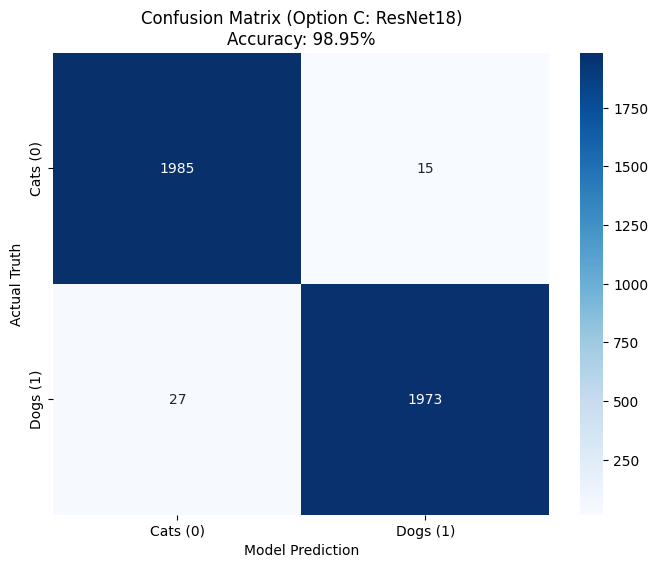

In [13]:
# 1. Gather all predictions and true labels from the Validation Set
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        # Move back to CPU to use with scikit-learn
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 2. Compute the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# 3. Plot it beautifully
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cats (0)', 'Dogs (1)'], 
            yticklabels=['Cats (0)', 'Dogs (1)'])
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.title(f'Confusion Matrix (Option C: ResNet18)\nAccuracy: {val_acc:.2f}%')
plt.show()


In [27]:
# Custom Dataset for Unlabeled Images
class KaggleTestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        self.test_dir = test_dir
        # Only grab .jpg files
        self.image_files = [f for f in os.listdir(test_dir) if f.endswith('.jpg')]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.test_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        # We must return the ID (which is the filename without .jpg) so Kaggle knows which image is which!
        image_id = img_name.split('.')[0] 
        return image, image_id

val_transform = transforms.Compose([
    transforms.Resize((256, 256)), # Resize a bit larger
    transforms.CenterCrop(224),    # Crop the exact center
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# setup the Test DataLoader
# IMPORTANT: We use val_transform here! No random cropping or flipping on test data!
test_dir = 'ecse-415-winter-2026-dog-vs-cat-classification/test/test'
test_dataset = KaggleTestDataset(test_dir, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# generate predictions
model.eval()
results = []

print("Running inference on Kaggle Test Set...")
with torch.no_grad():
    for images, image_ids in tqdm(test_loader, desc="Predicting"):
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        # Match each prediction with its Kaggle ID
        preds = predicted.cpu().numpy()
        for i in range(len(preds)):
            results.append({
                'id': image_ids[i],
                'label': preds[i]
            })

# Save to CSV
df_submission = pd.DataFrame(results)

# Kaggle requires the IDs to be sorted numerically (1, 2, 3...) not alphabetically (1, 10, 100...)
df_submission['id'] = pd.to_numeric(df_submission['id'])
df_submission = df_submission.sort_values('id')
df_submission.to_csv('resnet50_kaggle_submission.csv', index=False)

print("Success! \nSaved 'resnet50_kaggle_submission.csv' ready for upload.")

Running inference on Kaggle Test Set...


Predicting:   0%|          | 0/157 [00:00<?, ?it/s]

Success! 
Saved 'resnet50_kaggle_submission.csv' ready for upload.
